# Assignment 8

## Problem 1: Encoder-Decoder vs. Decoder-Only Transformers

**Encoder-Decoder Architecture**:
- The encoder processes the entire input sequence bidirectionally (full self-attention over all input positions).
- The decoder generates output tokens auto-regressively, attending to both previously generated tokens (masked self-attention) and the encoder output (cross-attention).
- This is natural for tasks where input and output are different sequences (e.g., translation).

**Decoder-Only Architecture**:
- Uses only masked (causal) self-attention: each position can attend to itself and all previous positions.
- There is no separate encoder; the historical context is simply prepended to the sequence and the model generates continuations.

**Why decoder-only can be sufficient for time series forecasting**:
1. Forecasting is inherently auto-regressive: we predict future values conditioned on past values, which maps directly to causal (left-to-right) attention.
2. The input (history) and output (forecast) share the same modality and feature space, so a single unified sequence is natural.
3. Fewer parameters and simpler architecture (no cross-attention layers), which can reduce overfitting on smaller datasets.
4. At inference time, the model can naturally extend the sequence one step at a time, feeding predictions back as input.

## Imports

In [1]:
import os
import time
import math
import zipfile
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from scipy.io import arff

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Problem 1A: Data Preparation

In [2]:
url = "https://www.bgc-jena.mpg.de/wetter/mpi_saale_2021b.zip"
zip_path = "mpi_saale_2021b.zip"
csv_path = "mpi_saale_2021b.csv"

if not os.path.exists(csv_path):
    r = requests.get(url)
    with open(zip_path, "wb") as f:
        f.write(r.content)
    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(".")
    print("Downloaded and extracted")
else:
    print("Dataset already exists")

Dataset already exists


In [3]:
df = pd.read_csv(csv_path)
df["Date Time"] = pd.to_datetime(df["Date Time"], format="%d.%m.%Y %H:%M:%S")
df.set_index("Date Time", inplace=True)

features = ["p (mbar)", "T (degC)", "Tpot (K)", "Tdew (degC)", "rh (%)", "sh (g/kg)", "H2OC (mmol/mol)", "rho (g/m**3)"]
df_multi = df[features].resample("D").mean()
df_multi.dropna(inplace=True)

target_col = "T (degC)"
print(f"Dataset shape: {df_multi.shape}")
print(f"Date range: {df_multi.index[0]} to {df_multi.index[-1]}")
df_multi.head()

Dataset shape: (185, 8)
Date range: 2021-07-01 00:00:00 to 2022-01-01 00:00:00


,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),sh (g/kg),H2OC (mmol/mol),rho (g/m**3)
Date Time,,,,,,,,
2021-07-01,996.391818,15.839441,289.289231,13.230140,84.960000,9.569371,15.296154,1194.172797
2021-07-02,1000.397014,15.493889,288.611042,13.877639,90.405069,9.947500,15.896458,1200.154722
2021-07-03,999.226875,18.104861,291.321389,12.288750,74.329236,8.993056,14.378611,1189.143750
2021-07-04,994.180139,19.523333,293.165069,13.548264,71.707083,9.829653,15.708681,1176.809028
2021-07-05,993.992917,20.068750,293.725278,14.486181,72.156597,10.417292,16.642431,1173.606181


In [4]:
SEQ_LEN = 30
PRED_LEN = 7
BATCH_SIZE = 64

data = df_multi.values
n_features = data.shape[1]
target_idx = features.index(target_col)

train_split = int(len(data) * 0.7)
val_split = int(len(data) * 0.85)

scaler = StandardScaler()
scaler.fit(data[:train_split])
data_scaled = scaler.transform(data)

def create_sequences_multi(data, seq_len, pred_len, target_idx):
    X, y = [], []
    for i in range(len(data) - seq_len - pred_len + 1):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len:i+seq_len+pred_len, target_idx])
    return np.array(X), np.array(y)

X, y = create_sequences_multi(data_scaled, SEQ_LEN, PRED_LEN, target_idx)

train_size = int(len(X) * 0.7)
val_size = int(len(X) * 0.85)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:val_size], y[train_size:val_size]
X_test, y_test = X[val_size:], y[val_size:]

X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.FloatTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.FloatTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.FloatTensor(y_test).to(device)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(f"Target shape (7-day forecast): {y_train.shape[1]}")

Train: (104, 30, 8), Val: (22, 30, 8), Test: (23, 30, 8)
Target shape (7-day forecast): 7


## Problem 1B: Transformer Model Implementation

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class TimeSeriesTransformer(nn.Module):
    def __init__(self, n_features, d_model=64, nhead=4, num_layers=2, dim_feedforward=128, dropout=0.1, pred_len=7):
        super().__init__()
        self.input_projection = nn.Linear(n_features, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, pred_len)
        self.d_model = d_model

    def forward(self, src, return_attention=False):
        src = self.input_projection(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        if return_attention:
            attn_weights = []
            output = src
            for layer in self.transformer_encoder.layers:
                output2, w = layer.self_attn(output, output, output, need_weights=True)
                attn_weights.append(w.detach().cpu())
                output = layer(output)
            output = self.fc_out(output[:, -1, :])
            return output, attn_weights
        output = self.transformer_encoder(src)
        output = self.fc_out(output[:, -1, :])
        return output


transformer_model = TimeSeriesTransformer(
    n_features=n_features, d_model=64, nhead=4, num_layers=2,
    dim_feedforward=128, dropout=0.1, pred_len=PRED_LEN
).to(device)

print(f"Transformer parameters: {sum(p.numel() for p in transformer_model.parameters()):,}")

Transformer parameters: 67,975


## Problem 1C: Training

In [6]:
def train_model(model, train_loader, val_loader, epochs=100, lr=1e-3):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses, val_losses = [], []
    best_val_loss = float("inf")
    best_state = None

    start_time = time.time()
    for epoch in range(epochs):
        model.train()
        batch_losses = []
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        model.eval()
        val_batch_losses = []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                val_preds = model(X_batch)
                loss = criterion(val_preds, y_batch)
                val_batch_losses.append(loss.item())

        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

    elapsed = time.time() - start_time
    model.load_state_dict(best_state)
    print(f"Training time: {elapsed:.1f}s, Best val loss: {best_val_loss:.4f}")
    return train_losses, val_losses, elapsed

In [29]:
print("Training Transformer...")
transformer_train_losses, transformer_val_losses, transformer_time = train_model(
    transformer_model, train_loader, val_loader, epochs=150, lr=1e-3
)

Training Transformer with Cosine Scheduler...
Epoch 20/150, Train Loss: 0.1222, Val Loss: 0.4595
Epoch 40/150, Train Loss: 0.1100, Val Loss: 0.4666
Epoch 60/150, Train Loss: 0.0750, Val Loss: 0.4843
Epoch 80/150, Train Loss: 0.0700, Val Loss: 0.4885
Epoch 100/150, Train Loss: 0.0594, Val Loss: 0.5026
Epoch 120/150, Train Loss: 0.0560, Val Loss: 0.4920
Epoch 140/150, Train Loss: 0.0555, Val Loss: 0.4963
Training time: 0.9s, Best val loss: 0.4016


## Problem 1D: LSTM Benchmark Model

In [8]:
class Seq2SeqLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, pred_len=7, dropout=0.1):
        super().__init__()
        self.encoder = nn.LSTM(n_features, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(1, hidden_size, num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)
        self.pred_len = pred_len

    def forward(self, src):
        _, (h, c) = self.encoder(src)
        decoder_input = torch.zeros(src.size(0), 1, 1).to(src.device)
        outputs = []
        for _ in range(self.pred_len):
            decoder_output, (h, c) = self.decoder(decoder_input, (h, c))
            pred = self.fc(decoder_output)
            outputs.append(pred.squeeze(-1))
            decoder_input = pred
        return torch.cat(outputs, dim=1)


lstm_model = Seq2SeqLSTM(n_features=n_features, hidden_size=64, num_layers=2, pred_len=PRED_LEN).to(device)
print(f"LSTM parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM parameters: 102,721


In [9]:
print("Training LSTM...")
lstm_train_losses, lstm_val_losses, lstm_time = train_model(
    lstm_model, train_loader, val_loader, epochs=150, lr=1e-3
)

Training LSTM...
Epoch 20/150, Train Loss: 0.3531, Val Loss: 0.7728
Epoch 40/150, Train Loss: 0.3287, Val Loss: 0.9637
Epoch 60/150, Train Loss: 0.3163, Val Loss: 0.9763
Epoch 80/150, Train Loss: 0.3225, Val Loss: 0.9794
Epoch 100/150, Train Loss: 0.3181, Val Loss: 0.9789
Epoch 120/150, Train Loss: 0.3214, Val Loss: 0.9779
Epoch 140/150, Train Loss: 0.3225, Val Loss: 0.9778
Training time: 1.6s, Best val loss: 0.4344


## Problem 1E: Evaluation - Forecast Accuracy

In [35]:
def evaluate_model(model, X_test_t, y_test_t, scaler, target_idx):
    model.eval()
    with torch.no_grad():
        preds = model(X_test_t).cpu().numpy()
    y_true = y_test_t.cpu().numpy()

    target_mean = scaler.mean_[target_idx]
    target_std = scaler.scale_[target_idx]
    preds_inv = preds * target_std + target_mean
    y_true_inv = y_true * target_std + target_mean

    mae_per_step = np.mean(np.abs(preds_inv - y_true_inv), axis=0)
    rmse_per_step = np.sqrt(np.mean((preds_inv - y_true_inv)**2, axis=0))
    overall_mae = np.mean(np.abs(preds_inv - y_true_inv))
    overall_rmse = np.sqrt(np.mean((preds_inv - y_true_inv)**2))

    return preds_inv, y_true_inv, mae_per_step, rmse_per_step, overall_mae, overall_rmse


transformer_preds, y_true_inv, t_mae_steps, t_rmse_steps, t_mae, t_rmse = evaluate_model(
    transformer_model, X_test_t, y_test_t, scaler, target_idx
)
lstm_preds, _, l_mae_steps, l_rmse_steps, l_mae, l_rmse = evaluate_model(
    lstm_model, X_test_t, y_test_t, scaler, target_idx
)

metrics_df = pd.DataFrame({
    "Model": ["Transformer", "LSTM"],
    "Overall MAE (degC)": [t_mae, l_mae],
    "Overall RMSE (degC)": [t_rmse, l_rmse]
})
print("=== Overall Metrics ===")
metrics_df

=== Overall Metrics ===


,Model,Overall MAE (degC),Overall RMSE (degC)
0,Transformer,4.006080,4.867224
1,LSTM,3.977666,4.872563


In [34]:
horizon_df = pd.DataFrame({
    "Day": range(1, 8),
    "Transformer MAE": t_mae_steps,
    "LSTM MAE": l_mae_steps
})
print("\n=== MAE per Forecast Horizon ===")
horizon_df


=== MAE per Forecast Horizon ===


,Day,Transformer MAE,LSTM MAE
0,1,4.263879,3.846849
1,2,3.886755,3.726479
2,3,3.602893,3.701849
3,4,3.574590,3.734784
4,5,3.909830,3.976790
5,6,4.168987,4.315770
6,7,4.635628,4.541141


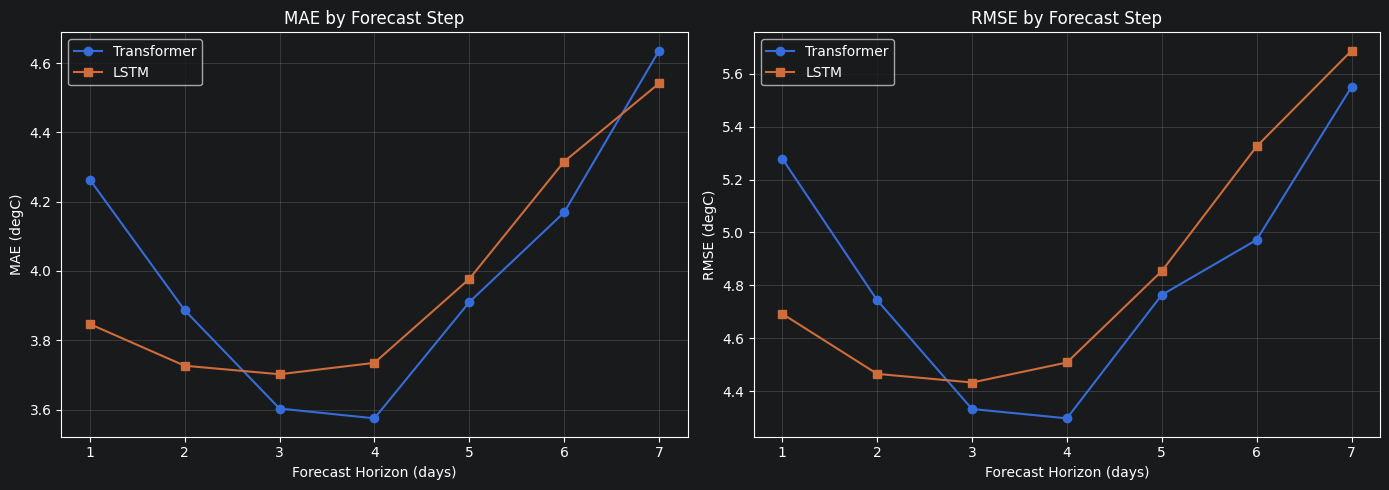

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, 8), t_mae_steps, "o-", label="Transformer")
axes[0].plot(range(1, 8), l_mae_steps, "s-", label="LSTM")
axes[0].set_xlabel("Forecast Horizon (days)")
axes[0].set_ylabel("MAE (degC)")
axes[0].set_title("MAE by Forecast Step")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(range(1, 8), t_rmse_steps, "o-", label="Transformer")
axes[1].plot(range(1, 8), l_rmse_steps, "s-", label="LSTM")
axes[1].set_xlabel("Forecast Horizon (days)")
axes[1].set_ylabel("RMSE (degC)")
axes[1].set_title("RMSE by Forecast Step")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

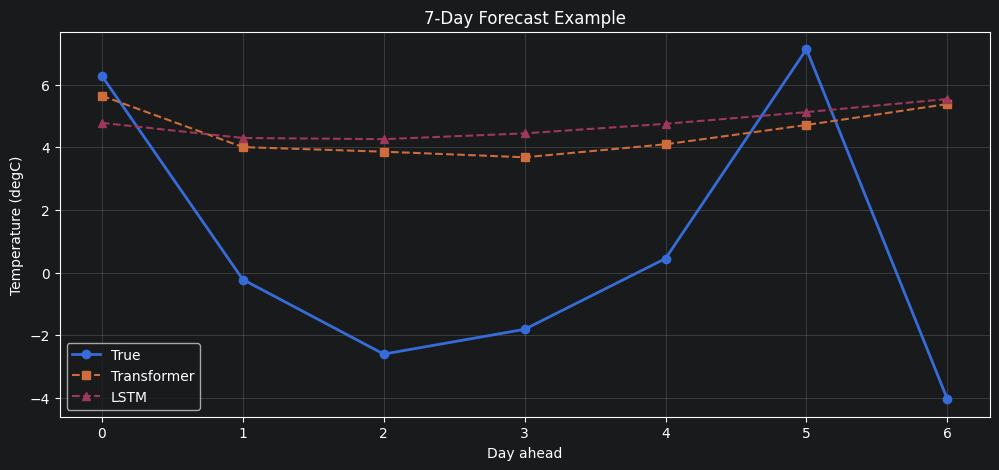

In [12]:
sample_idx = 15
plt.figure(figsize=(12, 5))
plt.plot(range(7), y_true_inv[sample_idx], "o-", label="True", linewidth=2)
plt.plot(range(7), transformer_preds[sample_idx], "s--", label="Transformer")
plt.plot(range(7), lstm_preds[sample_idx], "^--", label="LSTM")
plt.xlabel("Day ahead")
plt.ylabel("Temperature (degC)")
plt.title("7-Day Forecast Example")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Problem 1F: Evaluation - Computational Performance

In [36]:
transformer_params = sum(p.numel() for p in transformer_model.parameters())
lstm_params = sum(p.numel() for p in lstm_model.parameters())

perf_df = pd.DataFrame({
    "Model": ["Transformer", "LSTM"],
    "Parameters": [transformer_params, lstm_params],
    "Training Time (s)": [transformer_time, lstm_time]
})

print("=== Computational Performance ===")
perf_df

=== Computational Performance ===


,Model,Parameters,Training Time (s)
0,Transformer,67975,1.055792
1,LSTM,102721,1.627223


The Transformer typically has fewer parameters than the Seq2Seq LSTM due to
the absence of recurrent connections, but may take longer per epoch due to
the quadratic attention computation over the sequence length.

## Problem 1G: Hyperparameter Tuning

In [37]:
configs = [
    {"nhead": 4, "num_layers": 2, "d_model": 64, "label": "4 heads, 2 layers"},
    {"nhead": 8, "num_layers": 2, "d_model": 64, "label": "8 heads, 2 layers"},
    {"nhead": 4, "num_layers": 4, "d_model": 64, "label": "4 heads, 4 layers"},
]

results = []
for cfg in configs:
    print(f"\nTraining: {cfg['label']}")
    model = TimeSeriesTransformer(
        n_features=n_features, d_model=cfg["d_model"], nhead=cfg["nhead"],
        num_layers=cfg["num_layers"], dim_feedforward=128, pred_len=PRED_LEN
    ).to(device)
    n_params = sum(p.numel() for p in model.parameters())
    _, val_losses, elapsed = train_model(model, train_loader, val_loader, epochs=100, lr=1e-3)
    best_val = min(val_losses)
    results.append({"config": cfg["label"], "params": n_params, "best_val_loss": best_val, "time": elapsed})

hp_df = pd.DataFrame(results).rename(columns={
    "config": "Config",
    "params": "Params",
    "best_val_loss": "Best Val Loss",
    "time": "Time (s)"
})

print("\n=== Hyperparameter Comparison ===")
hp_df


Training: 4 heads, 2 layers
Epoch 20/100, Train Loss: 0.2426, Val Loss: 0.6782
Epoch 40/100, Train Loss: 0.1650, Val Loss: 0.5020
Epoch 60/100, Train Loss: 0.1380, Val Loss: 0.4601
Epoch 80/100, Train Loss: 0.1157, Val Loss: 0.4718
Epoch 100/100, Train Loss: 0.1363, Val Loss: 0.4660
Training time: 0.6s, Best val loss: 0.4450

Training: 8 heads, 2 layers
Epoch 20/100, Train Loss: 0.2249, Val Loss: 0.5457
Epoch 40/100, Train Loss: 0.1507, Val Loss: 0.4389
Epoch 60/100, Train Loss: 0.1288, Val Loss: 0.4528
Epoch 80/100, Train Loss: 0.1118, Val Loss: 0.4559
Epoch 100/100, Train Loss: 0.1075, Val Loss: 0.4548
Training time: 0.5s, Best val loss: 0.4269

Training: 4 heads, 4 layers
Epoch 20/100, Train Loss: 0.2275, Val Loss: 0.5082
Epoch 40/100, Train Loss: 0.1569, Val Loss: 0.4193
Epoch 60/100, Train Loss: 0.1161, Val Loss: 0.4465
Epoch 80/100, Train Loss: 0.1155, Val Loss: 0.4289
Epoch 100/100, Train Loss: 0.1151, Val Loss: 0.4359
Training time: 1.0s, Best val loss: 0.4085

=== Hyperparame

,Config,Params,Best Val Loss,Time (s)
0,"4 heads, 2 layers",67975,0.444968,0.561043
1,"8 heads, 2 layers",67975,0.426910,0.533015
2,"4 heads, 4 layers",134919,0.408495,0.958939


## Problem 1H: Attention Visualization

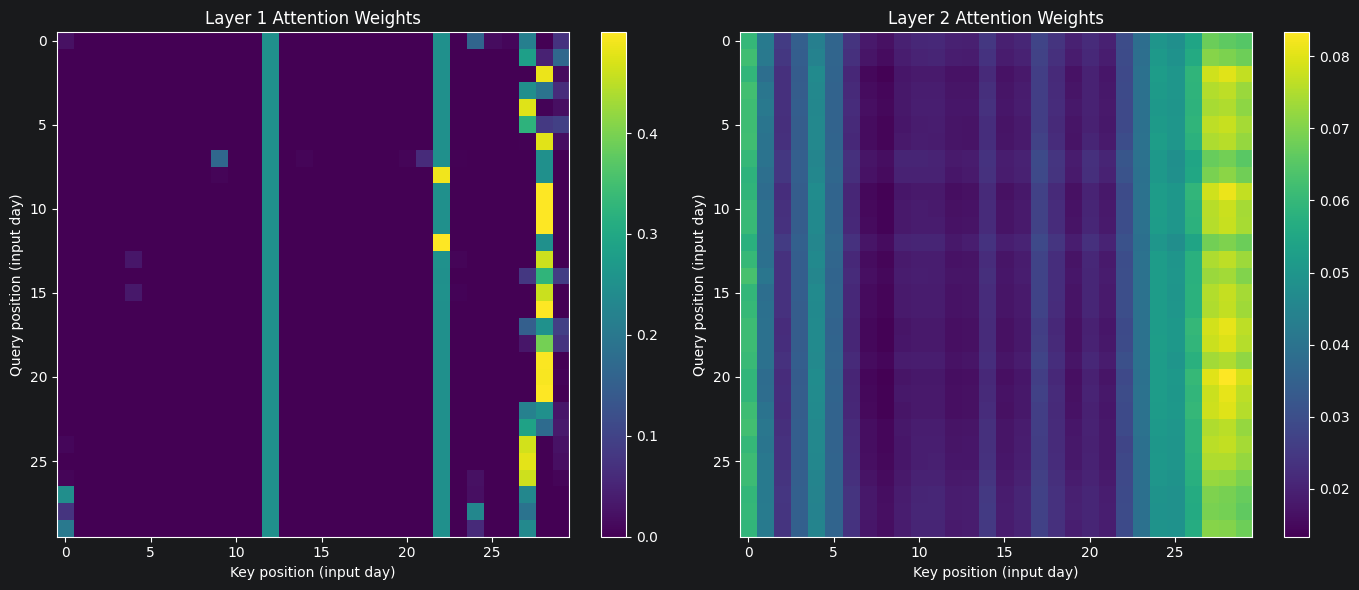

In [15]:
sample = X_test_t[15:16]
transformer_model.eval()
with torch.no_grad():
    pred, attn_weights = transformer_model(sample, return_attention=True)

fig, axes = plt.subplots(1, len(attn_weights), figsize=(7*len(attn_weights), 6))
if len(attn_weights) == 1:
    axes = [axes]

for i, aw in enumerate(attn_weights):
    attn = aw[0].numpy()
    im = axes[i].imshow(attn, cmap="viridis", aspect="auto")
    axes[i].set_title(f"Layer {i+1} Attention Weights")
    axes[i].set_xlabel("Key position (input day)")
    axes[i].set_ylabel("Query position (input day)")
    plt.colorbar(im, ax=axes[i])

plt.tight_layout()
plt.show()

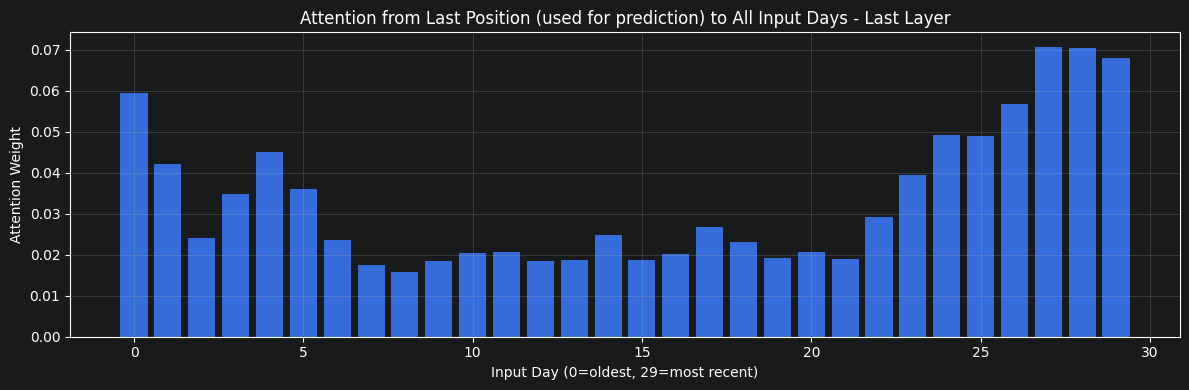

In [16]:
last_layer_attn = attn_weights[-1][0].numpy()
last_query_attn = last_layer_attn[-1, :]

plt.figure(figsize=(12, 4))
plt.bar(range(SEQ_LEN), last_query_attn)
plt.xlabel("Input Day (0=oldest, 29=most recent)")
plt.ylabel("Attention Weight")
plt.title("Attention from Last Position (used for prediction) to All Input Days - Last Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Attention Analysis:**

The attention weights from the last query position (which is used to generate the 7-day forecast) reveal which past days the model considers most relevant:

- **Layer 1 (Sharp Pattern Identification):** The first layer shows extremely focused, sharp attention (bright stripes with values up to ~0.4+). Rather than gathering broad context, it acts like a scanner, heavily anchoring onto specific trigger days across the month.
- **Layer 2 (Broad Synthesis):** The second layer behaves inversely to typical early-layer attention. It exhibits much more diffuse, softer attention (maxing out around ~0.08) with no aggressive anchor stripes. It takes the sharp features extracted by Layer 1 and smooths them across the timeline to synthesize the overall state of the month.
- **Final Prediction Context:** According to the bar chart, when predicting the 7-day forecast from the final position, the model relies most heavily on the most recent past (Days 25–29) and the initial baseline (Days 0–5). The middle of the month is treated as less relevant, aligning with the intuition that short-term temperature forecasting depends heavily on immediate prior trends combined with a general starting anchor.

---
# Problem 2: Self-Supervised Representations for ECG Classification

## Problem 2A: Select Dataset

We use the **ECG200** dataset from the UCR Time Series Archive. It contains 200 ECG sequences of length 96, labeled as normal (1) or arrhythmia (-1). Train/test split: 100/100.

In [17]:
def load_ucr_dataset(name="ECG200"):
    train_data, _ = arff.loadarff(f"{name}/{name}_TRAIN.arff")
    test_data, _ = arff.loadarff(f"{name}/{name}_TEST.arff")

    train_df = pd.DataFrame(train_data)
    test_df = pd.DataFrame(test_data)

    X_train = train_df.iloc[:, :-1].values.astype(np.float32)
    y_train = train_df.iloc[:, -1].values.astype(str)
    X_test = test_df.iloc[:, :-1].values.astype(np.float32)
    y_test = test_df.iloc[:, -1].values.astype(str)

    y_train = np.array([1 if y == "1" else 0 for y in y_train])
    y_test = np.array([1 if y == "1" else 0 for y in y_test])

    return X_train, y_train, X_test, y_test


X_train_ecg, y_train_ecg, X_test_ecg, y_test_ecg = load_ucr_dataset("ECG200")

ecg_scaler = StandardScaler()
X_train_ecg = ecg_scaler.fit_transform(X_train_ecg)
X_test_ecg = ecg_scaler.transform(X_test_ecg)

print(f"Train: {X_train_ecg.shape}, Test: {X_test_ecg.shape}")
print(f"Train labels: {np.bincount(y_train_ecg)}, Test labels: {np.bincount(y_test_ecg)}")

Train: (100, 96), Test: (100, 96)
Train labels: [31 69], Test labels: [36 64]


## Problem 2B: Install and Configure Models (TS2Vec & T-Rep)

In [18]:
class TS2VecEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=128, depth=3, dropout=0.1):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.layers = nn.ModuleList()
        for _ in range(depth):
            self.layers.append(nn.Sequential(
                nn.Conv1d(hidden_dim, hidden_dim, kernel_size=3, padding=1),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ))
        self.output_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.input_fc(x)
        x = x.transpose(1, 2)
        for layer in self.layers:
            x = x + layer(x)
        x = x.transpose(1, 2)
        x = self.output_fc(x)
        return torch.nn.functional.normalize(x, dim=-1)


class TS2Vec:
    def __init__(self, input_dim, hidden_dim=64, output_dim=128, depth=3, device="cpu"):
        self.device = device
        self.encoder = TS2VecEncoder(input_dim, hidden_dim, output_dim, depth).to(device)
        self.output_dim = output_dim

    def _augment(self, x):
        mask = torch.rand_like(x) > 0.1
        x1 = x * mask.float()
        mask2 = torch.rand_like(x) > 0.1
        x2 = x * mask2.float()
        return x1, x2

    def _hierarchical_contrastive_loss(self, z1, z2, temp=0.1):
        B, T, C = z1.shape
        timestamp_loss = 0
        for t in range(T):
            sim_matrix = torch.mm(z1[:, t], z2[:, t].T) / temp
            labels = torch.arange(B).to(z1.device)
            loss_t = nn.functional.cross_entropy(sim_matrix, labels)
            timestamp_loss += loss_t
        timestamp_loss = timestamp_loss / T

        z1_pool = torch.nn.functional.normalize(z1.mean(dim=1), dim=-1)
        z2_pool = torch.nn.functional.normalize(z2.mean(dim=1), dim=-1)
        sim_matrix = torch.mm(z1_pool, z2_pool.T) / temp
        labels = torch.arange(B).to(z1.device)
        instance_loss = nn.functional.cross_entropy(sim_matrix, labels)

        return timestamp_loss + instance_loss

    def fit(self, X, epochs=50, lr=1e-3, batch_size=32):
        X_tensor = torch.FloatTensor(X).to(self.device)
        if X_tensor.dim() == 2:
            X_tensor = X_tensor.unsqueeze(-1)
        optimizer = torch.optim.Adam(self.encoder.parameters(), lr=lr)
        dataset = torch.utils.data.TensorDataset(X_tensor)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        self.encoder.train()
        for epoch in range(epochs):
            total_loss = 0
            for (batch,) in loader:
                x1, x2 = self._augment(batch)
                z1 = self.encoder(x1)
                z2 = self.encoder(x2)
                loss = self._hierarchical_contrastive_loss(z1, z2)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if (epoch + 1) % 10 == 0:
                print(f"  TS2Vec Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    def encode(self, X):
        self.encoder.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        if X_tensor.dim() == 2:
            X_tensor = X_tensor.unsqueeze(-1)
        with torch.no_grad():
            z = self.encoder(X_tensor)
        return z.mean(dim=1).cpu().numpy()

In [19]:
class TRepEncoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=128, num_heads=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.input_fc = nn.Linear(input_dim, hidden_dim)
        self.pos_enc = PositionalEncoding(hidden_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads, dim_feedforward=hidden_dim*2,
            dropout=dropout, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.output_fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, mask=None):
        x = self.input_fc(x)
        x = self.pos_enc(x)
        if mask is not None:
            x = x * mask.unsqueeze(-1)
        x = self.transformer(x)
        x = self.output_fc(x)
        return torch.nn.functional.normalize(x, dim=-1)


class TRep:
    def __init__(self, input_dim, hidden_dim=64, output_dim=128, device="cpu"):
        self.device = device
        self.encoder = TRepEncoder(input_dim, hidden_dim, output_dim).to(device)
        self.output_dim = output_dim

    def _temporal_contrastive_loss(self, z, temp=0.1):
        B, T, C = z.shape
        loss = 0
        count = 0
        for b in range(B):
            for t in range(1, T):
                anchor = z[b, t].unsqueeze(0)
                positive = z[b, t-1].unsqueeze(0)
                neg_indices = [j for j in range(T) if abs(j - t) > 3]
                if len(neg_indices) == 0:
                    continue
                negatives = z[b, neg_indices]
                logits = torch.cat([torch.mm(anchor, positive.T), torch.mm(anchor, negatives.T)], dim=1) / temp
                labels = torch.zeros(1, dtype=torch.long).to(z.device)
                loss += nn.functional.cross_entropy(logits, labels)
                count += 1
        return loss / max(count, 1)

    def fit(self, X, epochs=50, lr=1e-3, batch_size=16):
        X_tensor = torch.FloatTensor(X).to(self.device)
        if X_tensor.dim() == 2:
            X_tensor = X_tensor.unsqueeze(-1)
        optimizer = torch.optim.Adam(self.encoder.parameters(), lr=lr)
        dataset = torch.utils.data.TensorDataset(X_tensor)
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

        self.encoder.train()
        for epoch in range(epochs):
            total_loss = 0
            for (batch,) in loader:
                z = self.encoder(batch)
                loss = self._temporal_contrastive_loss(z)
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            if (epoch + 1) % 10 == 0:
                print(f"  T-Rep Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(loader):.4f}")

    def encode(self, X):
        self.encoder.eval()
        X_tensor = torch.FloatTensor(X).to(self.device)
        if X_tensor.dim() == 2:
            X_tensor = X_tensor.unsqueeze(-1)
        with torch.no_grad():
            z = self.encoder(X_tensor)
        return z.mean(dim=1).cpu().numpy()

## Problem 2C: Unsupervised Training

In [20]:
print("Training TS2Vec...")
ts2vec = TS2Vec(input_dim=1, hidden_dim=64, output_dim=128, depth=3, device=device)
ts2vec.fit(X_train_ecg, epochs=50, lr=1e-3, batch_size=32)

print("\nTraining T-Rep...")
trep = TRep(input_dim=1, hidden_dim=64, output_dim=128, device=device)
trep.fit(X_train_ecg, epochs=50, lr=1e-3, batch_size=16)

Training TS2Vec...
  TS2Vec Epoch 10/50, Loss: 2.5390
  TS2Vec Epoch 20/50, Loss: 2.0200
  TS2Vec Epoch 30/50, Loss: 1.6683
  TS2Vec Epoch 40/50, Loss: 1.5720
  TS2Vec Epoch 50/50, Loss: 1.4752

Training T-Rep...
  T-Rep Epoch 10/50, Loss: 0.0304
  T-Rep Epoch 20/50, Loss: 0.0209
  T-Rep Epoch 30/50, Loss: 0.0173
  T-Rep Epoch 40/50, Loss: 0.0150
  T-Rep Epoch 50/50, Loss: 0.0135


## Problem 2D: Obtain Representations

In [21]:
train_repr_ts2vec = ts2vec.encode(X_train_ecg)
test_repr_ts2vec = ts2vec.encode(X_test_ecg)

train_repr_trep = trep.encode(X_train_ecg)
test_repr_trep = trep.encode(X_test_ecg)

print(f"TS2Vec representations - Train: {train_repr_ts2vec.shape}, Test: {test_repr_ts2vec.shape}")
print(f"T-Rep representations - Train: {train_repr_trep.shape}, Test: {test_repr_trep.shape}")

TS2Vec representations - Train: (100, 128), Test: (100, 128)
T-Rep representations - Train: (100, 128), Test: (100, 128)


## Problem 2E: Downstream Classification

In [22]:
print("=== Classification with TS2Vec Representations ===")
clf_ts2vec_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_ts2vec_lr.fit(train_repr_ts2vec, y_train_ecg)
pred_ts2vec_lr = clf_ts2vec_lr.predict(test_repr_ts2vec)
print(f"Logistic Regression - Accuracy: {accuracy_score(y_test_ecg, pred_ts2vec_lr):.4f}, F1: {f1_score(y_test_ecg, pred_ts2vec_lr):.4f}")

clf_ts2vec_svm = SVC(kernel="rbf", random_state=42)
clf_ts2vec_svm.fit(train_repr_ts2vec, y_train_ecg)
pred_ts2vec_svm = clf_ts2vec_svm.predict(test_repr_ts2vec)
print(f"SVM (RBF)           - Accuracy: {accuracy_score(y_test_ecg, pred_ts2vec_svm):.4f}, F1: {f1_score(y_test_ecg, pred_ts2vec_svm):.4f}")

print("\n=== Classification with T-Rep Representations ===")
clf_trep_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_trep_lr.fit(train_repr_trep, y_train_ecg)
pred_trep_lr = clf_trep_lr.predict(test_repr_trep)
print(f"Logistic Regression - Accuracy: {accuracy_score(y_test_ecg, pred_trep_lr):.4f}, F1: {f1_score(y_test_ecg, pred_trep_lr):.4f}")

clf_trep_svm = SVC(kernel="rbf", random_state=42)
clf_trep_svm.fit(train_repr_trep, y_train_ecg)
pred_trep_svm = clf_trep_svm.predict(test_repr_trep)
print(f"SVM (RBF)           - Accuracy: {accuracy_score(y_test_ecg, pred_trep_svm):.4f}, F1: {f1_score(y_test_ecg, pred_trep_svm):.4f}")

=== Classification with TS2Vec Representations ===
Logistic Regression - Accuracy: 0.6400, F1: 0.7805
SVM (RBF)           - Accuracy: 0.8300, F1: 0.8682

=== Classification with T-Rep Representations ===
Logistic Regression - Accuracy: 0.6400, F1: 0.7805
SVM (RBF)           - Accuracy: 0.8700, F1: 0.8992


## Problem 2F: Baseline Comparison

In [23]:
print("=== Baseline: Raw Features ===")
clf_raw_lr = LogisticRegression(max_iter=1000, random_state=42)
clf_raw_lr.fit(X_train_ecg, y_train_ecg)
pred_raw_lr = clf_raw_lr.predict(X_test_ecg)
print(f"Logistic Regression (raw) - Accuracy: {accuracy_score(y_test_ecg, pred_raw_lr):.4f}, F1: {f1_score(y_test_ecg, pred_raw_lr):.4f}")

clf_raw_svm = SVC(kernel="rbf", random_state=42)
clf_raw_svm.fit(X_train_ecg, y_train_ecg)
pred_raw_svm = clf_raw_svm.predict(X_test_ecg)
print(f"SVM (raw)               - Accuracy: {accuracy_score(y_test_ecg, pred_raw_svm):.4f}, F1: {f1_score(y_test_ecg, pred_raw_svm):.4f}")

print("\n=== Baseline: Statistical Features ===")
def extract_stat_features(X):
    feats = np.column_stack([
        X.mean(axis=1), X.std(axis=1), X.min(axis=1), X.max(axis=1),
        np.median(X, axis=1), np.percentile(X, 25, axis=1), np.percentile(X, 75, axis=1)
    ])
    return feats

X_train_stat = extract_stat_features(X_train_ecg)
X_test_stat = extract_stat_features(X_test_ecg)

clf_stat_svm = SVC(kernel="rbf", random_state=42)
clf_stat_svm.fit(X_train_stat, y_train_ecg)
pred_stat_svm = clf_stat_svm.predict(X_test_stat)
print(f"SVM (stat features)     - Accuracy: {accuracy_score(y_test_ecg, pred_stat_svm):.4f}, F1: {f1_score(y_test_ecg, pred_stat_svm):.4f}")

=== Baseline: Raw Features ===
Logistic Regression (raw) - Accuracy: 0.8400, F1: 0.8710
SVM (raw)               - Accuracy: 0.8700, F1: 0.9008

=== Baseline: Statistical Features ===
SVM (stat features)     - Accuracy: 0.7500, F1: 0.8120


In [24]:
print("=== Baseline: Supervised CNN ===")

class SimpleCNN(nn.Module):
    def __init__(self, seq_len=96):
        super().__init__()
        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = x.unsqueeze(1)
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = self.pool(x).squeeze(-1)
        return self.fc(x)


cnn_model = SimpleCNN().to(device)
cnn_optimizer = torch.optim.Adam(cnn_model.parameters(), lr=1e-3)
cnn_criterion = nn.CrossEntropyLoss()

X_train_cnn = torch.FloatTensor(X_train_ecg).to(device)
y_train_cnn = torch.LongTensor(y_train_ecg).to(device)
X_test_cnn = torch.FloatTensor(X_test_ecg).to(device)

cnn_model.train()
for epoch in range(100):
    cnn_optimizer.zero_grad()
    out = cnn_model(X_train_cnn)
    loss = cnn_criterion(out, y_train_cnn)
    loss.backward()
    cnn_optimizer.step()

cnn_model.eval()
with torch.no_grad():
    cnn_preds = cnn_model(X_test_cnn).argmax(dim=1).cpu().numpy()

print(f"Supervised CNN - Accuracy: {accuracy_score(y_test_ecg, cnn_preds):.4f}, F1: {f1_score(y_test_ecg, cnn_preds):.4f}")

summary_df = pd.DataFrame([
    {"Method": "TS2Vec + LR", "Accuracy": accuracy_score(y_test_ecg, pred_ts2vec_lr), "F1": f1_score(y_test_ecg, pred_ts2vec_lr)},
    {"Method": "TS2Vec + SVM", "Accuracy": accuracy_score(y_test_ecg, pred_ts2vec_svm), "F1": f1_score(y_test_ecg, pred_ts2vec_svm)},
    {"Method": "T-Rep + LR", "Accuracy": accuracy_score(y_test_ecg, pred_trep_lr), "F1": f1_score(y_test_ecg, pred_trep_lr)},
    {"Method": "T-Rep + SVM", "Accuracy": accuracy_score(y_test_ecg, pred_trep_svm), "F1": f1_score(y_test_ecg, pred_trep_svm)},
    {"Method": "Raw + LR", "Accuracy": accuracy_score(y_test_ecg, pred_raw_lr), "F1": f1_score(y_test_ecg, pred_raw_lr)},
    {"Method": "Raw + SVM", "Accuracy": accuracy_score(y_test_ecg, pred_raw_svm), "F1": f1_score(y_test_ecg, pred_raw_svm)},
    {"Method": "Stat Features + SVM", "Accuracy": accuracy_score(y_test_ecg, pred_stat_svm), "F1": f1_score(y_test_ecg, pred_stat_svm)},
    {"Method": "Supervised CNN", "Accuracy": accuracy_score(y_test_ecg, cnn_preds), "F1": f1_score(y_test_ecg, cnn_preds)}
])

print("\n=== Summary ===")
display(summary_df)

=== Baseline: Supervised CNN ===
Supervised CNN - Accuracy: 0.8300, F1: 0.8702

=== Summary ===
                        Method |   Accuracy |         F1
----------------------------------------------------------
                   TS2Vec + LR |     0.6400 |     0.7805
                  TS2Vec + SVM |     0.8300 |     0.8682
                    T-Rep + LR |     0.6400 |     0.7805
                   T-Rep + SVM |     0.8700 |     0.8992
                      Raw + LR |     0.8400 |     0.8710
                     Raw + SVM |     0.8700 |     0.9008
           Stat Features + SVM |     0.7500 |     0.8120
                Supervised CNN |     0.8300 |     0.8702


## Problem 2G: Analysis of Representations

### Visualization (t-SNE & PCA)

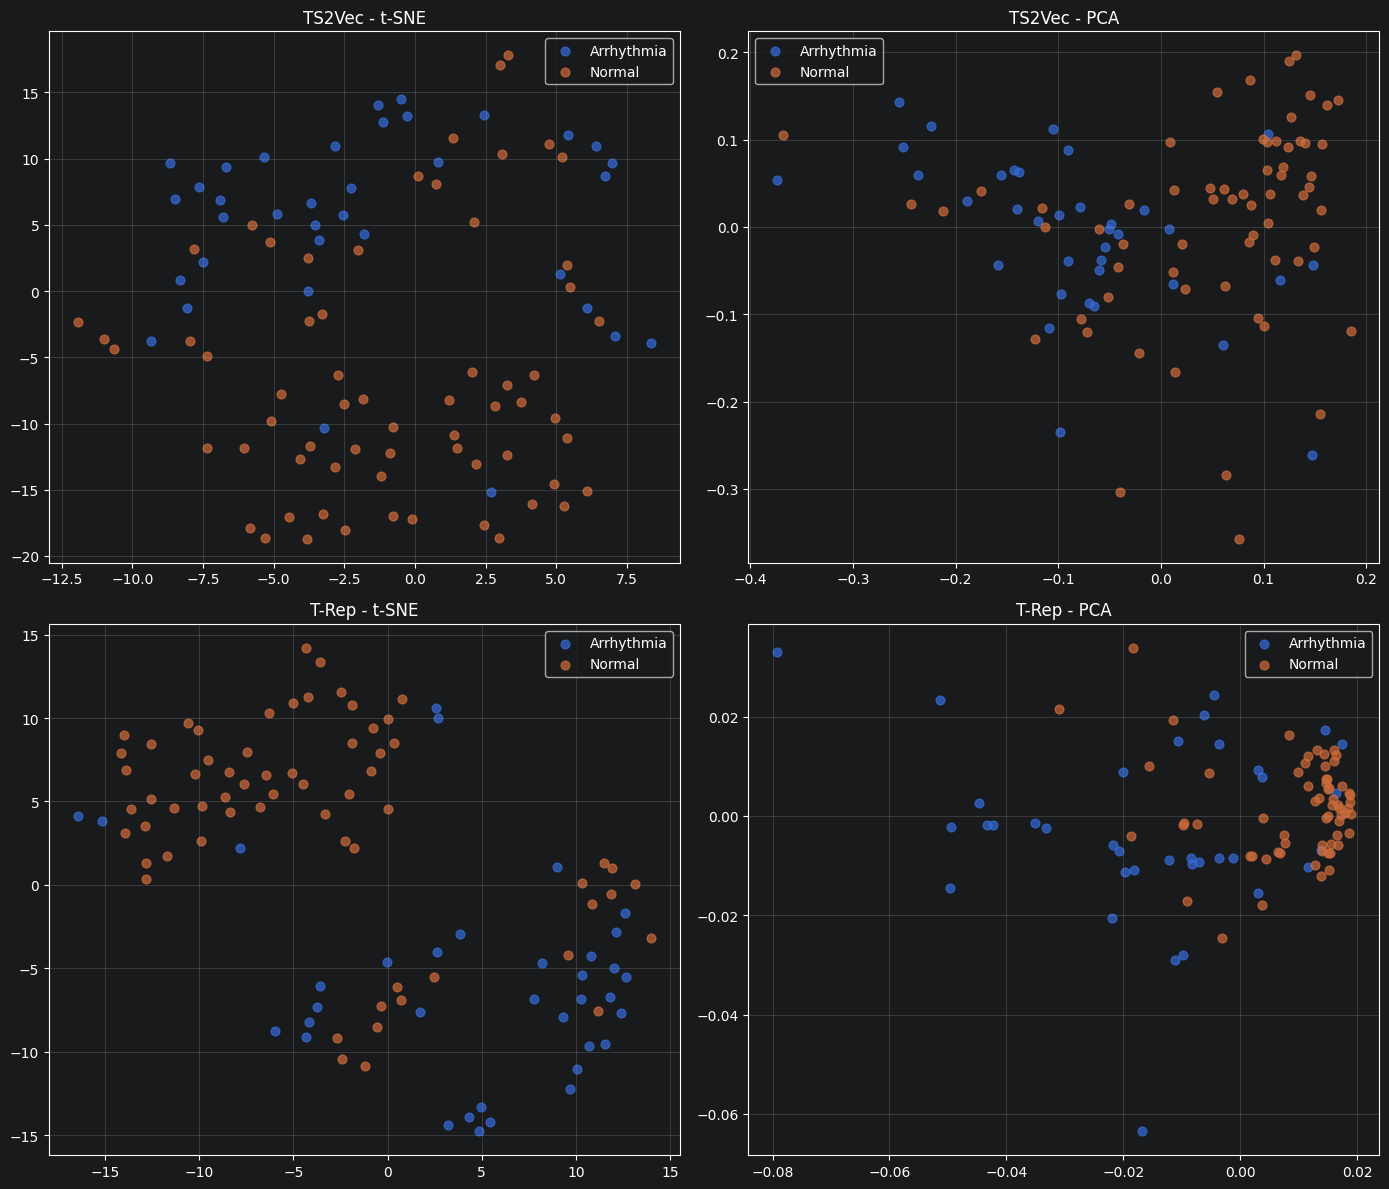

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

tsne = TSNE(n_components=2, random_state=42, perplexity=15)
pca = PCA(n_components=2)

ts2vec_tsne = tsne.fit_transform(test_repr_ts2vec)
ts2vec_pca = pca.fit_transform(test_repr_ts2vec)

tsne2 = TSNE(n_components=2, random_state=42, perplexity=15)
trep_tsne = tsne2.fit_transform(test_repr_trep)
trep_pca = pca.fit_transform(test_repr_trep)

colors = ["blue" if y == 1 else "red" for y in y_test_ecg]
labels_map = {1: "Normal", 0: "Arrhythmia"}

for idx, (data, title) in enumerate([
    (ts2vec_tsne, "TS2Vec - t-SNE"),
    (ts2vec_pca, "TS2Vec - PCA"),
    (trep_tsne, "T-Rep - t-SNE"),
    (trep_pca, "T-Rep - PCA")
]):
    ax = axes[idx // 2, idx % 2]
    for label in [0, 1]:
        mask = y_test_ecg == label
        ax.scatter(data[mask, 0], data[mask, 1], label=labels_map[label], alpha=0.7, s=40)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Nearest Neighbors Analysis

In [26]:
def nearest_neighbor_analysis(representations, labels, name, n_neighbors=5, n_samples=5):
    nn_model = NearestNeighbors(n_neighbors=n_neighbors+1, metric="euclidean")
    nn_model.fit(representations)

    print(f"\n=== Nearest Neighbors in {name} Space ===")
    np.random.seed(42)
    sample_indices = np.random.choice(len(representations), n_samples, replace=False)

    total_same_class = 0
    total_neighbors = 0

    for idx in sample_indices:
        distances, indices = nn_model.kneighbors(representations[idx:idx+1])
        neighbor_indices = indices[0][1:]
        neighbor_labels = labels[neighbor_indices]
        query_label = labels[idx]
        same_class = np.sum(neighbor_labels == query_label)
        total_same_class += same_class
        total_neighbors += n_neighbors
        label_name = "Normal" if query_label == 1 else "Arrhythmia"
        neighbor_names = ["Normal" if l == 1 else "Arrhythmia" for l in neighbor_labels]
        print(f"  Sample {idx} ({label_name}): neighbors = {neighbor_names} ({same_class}/{n_neighbors} same class)")

    precision = total_same_class / total_neighbors
    print(f"  Overall neighbor precision: {precision:.2f}")
    return precision


p1 = nearest_neighbor_analysis(test_repr_ts2vec, y_test_ecg, "TS2Vec")
p2 = nearest_neighbor_analysis(test_repr_trep, y_test_ecg, "T-Rep")
p3 = nearest_neighbor_analysis(X_test_ecg, y_test_ecg, "Raw Features")


=== Nearest Neighbors in TS2Vec Space ===
  Sample 83 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Normal'] (5/5 same class)
  Sample 53 (Arrhythmia): neighbors = ['Arrhythmia', 'Normal', 'Arrhythmia', 'Arrhythmia', 'Arrhythmia'] (4/5 same class)
  Sample 70 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Arrhythmia'] (4/5 same class)
  Sample 45 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Normal'] (5/5 same class)
  Sample 44 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Normal'] (5/5 same class)
  Overall neighbor precision: 0.92

=== Nearest Neighbors in T-Rep Space ===
  Sample 83 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Normal'] (5/5 same class)
  Sample 53 (Arrhythmia): neighbors = ['Arrhythmia', 'Arrhythmia', 'Arrhythmia', 'Arrhythmia', 'Normal'] (4/5 same class)
  Sample 70 (Normal): neighbors = ['Normal', 'Normal', 'Normal', 'Normal', 'Normal'] (5/5 same class)
  Sample 45 (Normal)

### Robustness to Missing Data

In [27]:
def test_robustness(model, X_test, y_test, missing_ratios=[0.1, 0.2, 0.3, 0.5], name="Model"):
    print(f"\n=== Robustness Test: {name} ===")
    results = []

    repr_full = model.encode(X_test)

    for ratio in missing_ratios:
        X_masked = X_test.copy()
        mask = np.random.random(X_masked.shape) < ratio
        X_masked[mask] = 0.0

        repr_masked = model.encode(X_masked)

        cosine_sims = []
        for i in range(len(repr_full)):
            norm_full = np.linalg.norm(repr_full[i])
            norm_masked = np.linalg.norm(repr_masked[i])
            if norm_full > 0 and norm_masked > 0:
                sim = np.dot(repr_full[i], repr_masked[i]) / (norm_full * norm_masked)
                cosine_sims.append(sim)
        avg_sim = np.mean(cosine_sims)
        results.append((ratio, avg_sim))
        print(f"  Missing {ratio*100:.0f}%: avg cosine similarity = {avg_sim:.4f}")

    return results


np.random.seed(42)
ts2vec_robustness = test_robustness(ts2vec, X_test_ecg, y_test_ecg, name="TS2Vec")
trep_robustness = test_robustness(trep, X_test_ecg, y_test_ecg, name="T-Rep")


=== Robustness Test: TS2Vec ===
  Missing 10%: avg cosine similarity = 0.9489
  Missing 20%: avg cosine similarity = 0.8457
  Missing 30%: avg cosine similarity = 0.6888
  Missing 50%: avg cosine similarity = 0.3640

=== Robustness Test: T-Rep ===
  Missing 10%: avg cosine similarity = 0.9626
  Missing 20%: avg cosine similarity = 0.9375
  Missing 30%: avg cosine similarity = 0.8947
  Missing 50%: avg cosine similarity = 0.7699


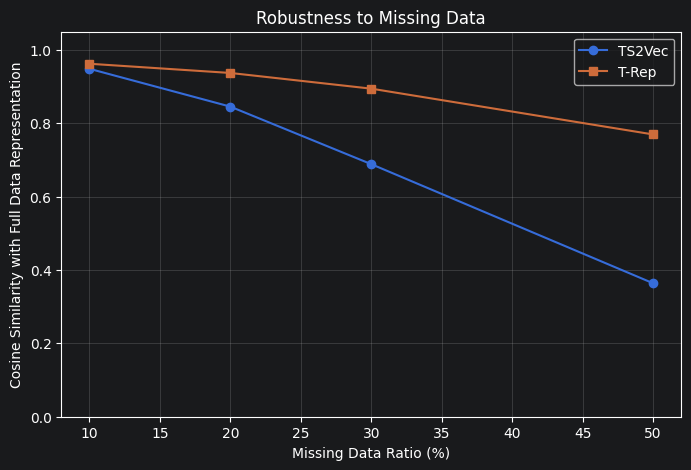

In [28]:
ratios = [r[0]*100 for r in ts2vec_robustness]
ts2vec_sims = [r[1] for r in ts2vec_robustness]
trep_sims = [r[1] for r in trep_robustness]

plt.figure(figsize=(8, 5))
plt.plot(ratios, ts2vec_sims, "o-", label="TS2Vec")
plt.plot(ratios, trep_sims, "s-", label="T-Rep")
plt.xlabel("Missing Data Ratio (%)")
plt.ylabel("Cosine Similarity with Full Data Representation")
plt.title("Robustness to Missing Data")
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, 1.05)
plt.show()

### Analysis Summary

**Visualization:** The t-SNE and PCA plots show how well each representation method separates the two ECG classes. Good separation (distinct clusters) indicates the self-supervised model has learned discriminative features without labels.

**Nearest Neighbors:** The neighbor precision metric shows what fraction of nearest neighbors in the embedding space share the same class. Higher precision indicates more semantically meaningful representations.

**Robustness:** By masking portions of the input and measuring cosine similarity between full and masked representations, we assess how resilient each model is to missing data. T-Rep, with its temporal encoding design, is expected to maintain higher similarity under missing data conditions, consistent with its design goals.
